<a href="https://colab.research.google.com/github/ancestor9/2026_Fall_Deep-Learning-with-Python/blob/main/scripts/chapter14_text_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

This is a companion notebook for the book [Deep Learning with Python, Third Edition](https://www.manning.com/books/deep-learning-with-python-third-edition). For readability, it only contains runnable code blocks and section titles, and omits everything else in the book: text paragraphs, figures, and pseudocode.

**If you want to be able to follow what's going on, I recommend reading the notebook side by side with your copy of the book.**

The book's contents are available online at [deeplearningwithpython.io](https://deeplearningwithpython.io).

In [27]:
!pip install keras keras-hub --upgrade -q

In [28]:
import os
os.environ["KERAS_BACKEND"] = "jax"

In [29]:
# @title
import os
from IPython.core.magic import register_cell_magic

@register_cell_magic
def backend(line, cell):
    current, required = os.environ.get("KERAS_BACKEND", ""), line.split()[-1]
    if current == required:
        get_ipython().run_cell(cell)
    else:
        print(
            f"This cell requires the {required} backend. To run it, change KERAS_BACKEND to "
            f"\"{required}\" at the top of the notebook, restart the runtime, and rerun the notebook."
        )

## Text classification

### A brief history of natural language processing

### Preparing text data

In [30]:
import regex as re

def split_chars(text):
    return re.findall(r".", text)

In [31]:
chars = split_chars("The quick brown fox jumped over the lazy dog.")
chars[:12]

['T', 'h', 'e', ' ', 'q', 'u', 'i', 'c', 'k', ' ', 'b', 'r']

In [32]:
def split_words(text):
    return re.findall(r"[\w]+|[.,!?;]", text)

In [33]:
split_words("The quick brown fox jumped over the dog.")

['The', 'quick', 'brown', 'fox', 'jumped', 'over', 'the', 'dog', '.']

In [34]:
vocabulary = {
    "[UNK]": 0,
    "the": 1,
    "quick": 2,
    "brown": 3,
    "fox": 4,
    "jumped": 5,
    "over": 6,
    "dog": 7,
    ".": 8,
}
words = split_words("The quick brown fox jumped over the lazy dog.")
indices = [vocabulary.get(word, 0) for word in words]

#### Character and word tokenization

In [35]:
class CharTokenizer:
    def __init__(self, vocabulary):
        self.vocabulary = vocabulary
        self.unk_id = vocabulary["[UNK]"]

    def standardize(self, inputs):
        return inputs.lower()

    def split(self, inputs):
        return re.findall(r".", inputs)

    def index(self, tokens):
        return [self.vocabulary.get(t, self.unk_id) for t in tokens]

    def __call__(self, inputs):
        inputs = self.standardize(inputs)
        tokens = self.split(inputs)
        indices = self.index(tokens)
        return indices

In [36]:
import collections

def compute_char_vocabulary(inputs, max_size):
    char_counts = collections.Counter()
    for x in inputs:
        x = x.lower()
        tokens = re.findall(r".", x)
        char_counts.update(tokens)
    vocabulary = ["[UNK]"]
    most_common = char_counts.most_common(max_size - len(vocabulary))
    for token, count in most_common:
        vocabulary.append(token)
    return dict((token, i) for i, token in enumerate(vocabulary))

In [37]:
class WordTokenizer:
    def __init__(self, vocabulary):
        self.vocabulary = vocabulary
        self.unk_id = vocabulary["[UNK]"]

    def standardize(self, inputs):
        return inputs.lower()

    def split(self, inputs):
        return re.findall(r"[\w]+|[.,!?;]", inputs)

    def index(self, tokens):
        return [self.vocabulary.get(t, self.unk_id) for t in tokens]

    def __call__(self, inputs):
        inputs = self.standardize(inputs)
        tokens = self.split(inputs)
        indices = self.index(tokens)
        return indices

In [38]:
def compute_word_vocabulary(inputs, max_size):
    word_counts = collections.Counter()
    for x in inputs:
        x = x.lower()
        tokens = re.findall(r"[\w]+|[.,!?;]", x)
        word_counts.update(tokens)
    vocabulary = ["[UNK]"]
    most_common = word_counts.most_common(max_size - len(vocabulary))
    for token, count in most_common:
        vocabulary.append(token)
    return dict((token, i) for i, token in enumerate(vocabulary))

In [39]:
import keras

filename = keras.utils.get_file(
    origin="https://www.gutenberg.org/files/2701/2701-0.txt",
    fname="moby_dick.txt"
)
moby_dick = list(open(filename, "r"))

vocabulary = compute_char_vocabulary(moby_dick, max_size=100)
char_tokenizer = CharTokenizer(vocabulary)

In [40]:
len(moby_dick)

21936

In [41]:
vocabulary.keys()

dict_keys(['[UNK]', ' ', 'e', 't', 'a', 'o', 'n', 'i', 's', 'h', 'r', 'l', 'd', 'u', 'm', 'c', 'w', 'f', 'g', ',', 'p', 'b', 'y', 'v', 'k', '.', ';', '’', '-', '!', '—', '“', 'q', '”', 'j', 'x', '?', '_', 'z', '(', ')', '1', ':', '0', '‘', '2', '*', '8', '7', '5', '3', '4', '6', '9', 'æ', 'œ', 'é', '£', 'è', '$', '[', ']', '&', '\u200f', 'ח', 'ו', '\u200e', 'ϰ', 'η', 'τ', 'ο', 'ς', 'â'])

In [42]:
print("Vocabulary length:", len(vocabulary))

Vocabulary length: 73


In [43]:
print("Vocabulary start:", list(vocabulary.keys())[:10])

Vocabulary start: ['[UNK]', ' ', 'e', 't', 'a', 'o', 'n', 'i', 's', 'h']


In [44]:
print("Vocabulary end:", list(vocabulary.keys())[-10:])

Vocabulary end: ['\u200f', 'ח', 'ו', '\u200e', 'ϰ', 'η', 'τ', 'ο', 'ς', 'â']


In [45]:
print("Line length:", len(char_tokenizer(
   "Call me Ishmael. Some years ago--never mind how long precisely."
)))

Line length: 63


In [46]:
vocabulary = compute_word_vocabulary(moby_dick, max_size=2_000)
word_tokenizer = WordTokenizer(vocabulary)

In [47]:
print("Vocabulary length:", len(vocabulary))

Vocabulary length: 2000


In [48]:
print("Vocabulary start:", list(vocabulary.keys())[:5])

Vocabulary start: ['[UNK]', ',', 'the', '.', 'of']


In [49]:
print("Vocabulary end:", list(vocabulary.keys())[-5:])

Vocabulary end: ['beholding', 'hearse', 'mount', 'tackle', 'objects']


In [50]:
word_tokenizer(
   "Call me Ishmael. Some years ago--never mind how long precisely."
)

[407, 47, 1021, 3, 49, 248, 607, 145, 296, 117, 87, 795, 3]

In [51]:
print("Line length:", len(word_tokenizer(
   "Call me Ishmael. Some years ago--never mind how long precisely."
)))

Line length: 13


#### Subword tokenization

In [52]:
data = [
    "the quick brown fox",
    "the slow brown fox",
    "the quick brown foxhound",
]

In [53]:
def count_and_split_words(data):
    counts = collections.Counter()
    for line in data:
        line = line.lower()
        for word in re.findall(r"[\w]+|[.,!?;]", line):
            chars = re.findall(r".", word)
            split_word = " ".join(chars)
            counts[split_word] += 1
    return dict(counts)

counts = count_and_split_words(data)

In [54]:
counts

{'t h e': 3,
 'q u i c k': 2,
 'b r o w n': 3,
 'f o x': 2,
 's l o w': 1,
 'f o x h o u n d': 1}

In [55]:
def count_pairs(counts):
    pairs = collections.Counter()
    for word, freq in counts.items():
        symbols = word.split()
        for pair in zip(symbols[:-1], symbols[1:]):
            pairs[pair] += freq
    return pairs

def merge_pair(counts, first, second):
    split = re.compile(f"(?<!\\S){first} {second}(?!\\S)")
    merged = f"{first}{second}"
    return {split.sub(merged, word): count for word, count in counts.items()}

for i in range(10):
    pairs = count_pairs(counts)
    if not pairs:
        break
    first, second = max(pairs, key=pairs.get)
    counts = merge_pair(counts, first, second)
    print(list(counts.keys()))

['t h e', 'q u i c k', 'b r ow n', 'f o x', 's l ow', 'f o x h o u n d']
['th e', 'q u i c k', 'b r ow n', 'f o x', 's l ow', 'f o x h o u n d']
['the', 'q u i c k', 'b r ow n', 'f o x', 's l ow', 'f o x h o u n d']
['the', 'q u i c k', 'br ow n', 'f o x', 's l ow', 'f o x h o u n d']
['the', 'q u i c k', 'brow n', 'f o x', 's l ow', 'f o x h o u n d']
['the', 'q u i c k', 'brown', 'f o x', 's l ow', 'f o x h o u n d']
['the', 'q u i c k', 'brown', 'fo x', 's l ow', 'fo x h o u n d']
['the', 'q u i c k', 'brown', 'fox', 's l ow', 'fox h o u n d']
['the', 'qu i c k', 'brown', 'fox', 's l ow', 'fox h o u n d']
['the', 'qui c k', 'brown', 'fox', 's l ow', 'fox h o u n d']


In [56]:
def compute_sub_word_vocabulary(dataset, vocab_size):
    counts = count_and_split_words(dataset)

    char_counts = collections.Counter()
    for word in counts:
        for char in word.split():
            char_counts[char] += counts[word]
    most_common = char_counts.most_common()
    vocab = ["[UNK]"] + [char for char, freq in most_common]
    merges = []

    while len(vocab) < vocab_size:
        pairs = count_pairs(counts)
        if not pairs:
            break
        first, second = max(pairs, key=pairs.get)
        counts = merge_pair(counts, first, second)
        vocab.append(f"{first}{second}")
        merges.append(f"{first} {second}")

    vocab = dict((token, index) for index, token in enumerate(vocab))
    merges = dict((token, rank) for rank, token in enumerate(merges))
    return vocab, merges

In [57]:
class SubWordTokenizer:
    def __init__(self, vocabulary, merges):
        self.vocabulary = vocabulary
        self.merges = merges
        self.unk_id = vocabulary["[UNK]"]

    def standardize(self, inputs):
        return inputs.lower()

    def bpe_merge(self, word):
        while True:
            pairs = re.findall(r"(?<!\S)\S+ \S+(?!\S)", word, overlapped=True)
            if not pairs:
                break
            best = min(pairs, key=lambda pair: self.merges.get(pair, 1e9))
            if best not in self.merges:
                break
            first, second = best.split()
            split = re.compile(f"(?<!\S){first} {second}(?!\S)")
            merged = f"{first}{second}"
            word = split.sub(merged, word)
        return word

    def split(self, inputs):
        tokens = []
        for word in re.findall(r"[\w]+|[.,!?;]", inputs):
            word = " ".join(re.findall(r".", word))
            word = self.bpe_merge(word)
            tokens.extend(word.split())
        return tokens

    def index(self, tokens):
        return [self.vocabulary.get(t, self.unk_id) for t in tokens]

    def __call__(self, inputs):
        inputs = self.standardize(inputs)
        tokens = self.split(inputs)
        indices = self.index(tokens)
        return indices

<>:19: SyntaxWarning: invalid escape sequence '\S'
<>:19: SyntaxWarning: invalid escape sequence '\S'
<>:19: SyntaxWarning: invalid escape sequence '\S'
<>:19: SyntaxWarning: invalid escape sequence '\S'
/tmp/ipykernel_7137/759452212.py:19: SyntaxWarning: invalid escape sequence '\S'
  split = re.compile(f"(?<!\S){first} {second}(?!\S)")
/tmp/ipykernel_7137/759452212.py:19: SyntaxWarning: invalid escape sequence '\S'
  split = re.compile(f"(?<!\S){first} {second}(?!\S)")


In [58]:
vocabulary, merges = compute_sub_word_vocabulary(moby_dick, 2_000)
sub_word_tokenizer = SubWordTokenizer(vocabulary, merges)

In [59]:
print("Vocabulary length:", len(vocabulary))

Vocabulary length: 2000


In [60]:
print("Vocabulary start:", list(vocabulary.keys())[:10])

Vocabulary start: ['[UNK]', 'e', 't', 'a', 'o', 'n', 'i', 's', 'h', 'r']


In [61]:
print("Vocabulary end:", list(vocabulary.keys())[-7:])

Vocabulary end: ['stret', 'breath', 'na', 'thern', 'armed', 'fishermen', 'bright']


In [62]:
print("Line length:", len(sub_word_tokenizer(
   "Call me Ishmael. Some years ago--never mind how long precisely."
)))

Line length: 16


In [63]:
full_moby_dick_text = " ".join(moby_dick)
tokenized_moby_dick = sub_word_tokenizer(full_moby_dick_text)
print("First 20 tokens:", tokenized_moby_dick[:20])

First 20 tokens: [867, 71, 56, 271, 749, 17, 210, 68, 457, 17, 1, 942, 35, 37, 34, 33, 898, 899, 25, 73]


In [64]:
print("Length of tokenized moby_dick:", len(tokenized_moby_dick))

Length of tokenized moby_dick: 339308


### Sets vs. sequences

#### Loading the IMDb classification dataset

In [65]:
import os, pathlib, shutil, random

zip_path = keras.utils.get_file(
    origin="https://ai.stanford.edu/~amaas/data/sentiment/aclImdb_v1.tar.gz",
    fname="imdb",
    extract=True,
)

imdb_extract_dir = pathlib.Path(zip_path) / "aclImdb"

In [66]:
for path in imdb_extract_dir.glob("*/*"):
    if path.is_dir():
        print(path)

/root/.keras/datasets/imdb/aclImdb/train/unsup
/root/.keras/datasets/imdb/aclImdb/train/neg
/root/.keras/datasets/imdb/aclImdb/train/pos
/root/.keras/datasets/imdb/aclImdb/test/neg
/root/.keras/datasets/imdb/aclImdb/test/pos


In [67]:
print(open(imdb_extract_dir / "train" / "pos" / "4077_10.txt", "r").read())

I first saw this back in the early 90s on UK TV, i did like it then but i missed the chance to tape it, many years passed but the film always stuck with me and i lost hope of seeing it TV again, the main thing that stuck with me was the end, the hole castle part really touched me, its easy to watch, has a great story, great music, the list goes on and on, its OK me saying how good it is but everyone will take there own best bits away with them once they have seen it, yes the animation is top notch and beautiful to watch, it does show its age in a very few parts but that has now become part of it beauty, i am so glad it has came out on DVD as it is one of my top 10 films of all time. Buy it or rent it just see it, best viewing is at night alone with drink and food in reach so you don't have to stop the film.<br /><br />Enjoy


In [69]:
train_dir = pathlib.Path("imdb_train")
test_dir = pathlib.Path("imdb_test")
val_dir = pathlib.Path("imdb_val")

# Remove existing directories to ensure a clean slate
if train_dir.exists():
    shutil.rmtree(train_dir)
if test_dir.exists():
    shutil.rmtree(test_dir)
if val_dir.exists():
    shutil.rmtree(val_dir)

shutil.copytree(imdb_extract_dir / "test", test_dir)

val_percentage = 0.2
for category in ("neg", "pos"):
    src_dir = imdb_extract_dir / "train" / category
    src_files = os.listdir(src_dir)
    random.Random(1337).shuffle(src_files)
    num_val_samples = int(len(src_files) * val_percentage)

    os.makedirs(val_dir / category)
    for file in src_files[:num_val_samples]:
        shutil.copy(src_dir / file, val_dir / category / file)
    os.makedirs(train_dir / category)
    for file in src_files[num_val_samples:]:
        shutil.copy(src_dir / file, train_dir / category / file)

In [70]:
from keras.utils import text_dataset_from_directory

batch_size = 32
train_ds = text_dataset_from_directory(train_dir, batch_size=batch_size)
val_ds = text_dataset_from_directory(val_dir, batch_size=batch_size)
test_ds = text_dataset_from_directory(test_dir, batch_size=batch_size)

Found 20000 files belonging to 2 classes.
Found 5000 files belonging to 2 classes.
Found 25000 files belonging to 2 classes.


### Set models

#### Training a bag-of-words model

In [71]:
from keras import layers

max_tokens = 20_000
text_vectorization = layers.TextVectorization(
    max_tokens=max_tokens,
    split="whitespace",
    output_mode="multi_hot",
)
train_ds_no_labels = train_ds.map(lambda x, y: x)
text_vectorization.adapt(train_ds_no_labels)

bag_of_words_train_ds = train_ds.map(
    lambda x, y: (text_vectorization(x), y), num_parallel_calls=8
)
bag_of_words_val_ds = val_ds.map(
    lambda x, y: (text_vectorization(x), y), num_parallel_calls=8
)
bag_of_words_test_ds = test_ds.map(
    lambda x, y: (text_vectorization(x), y), num_parallel_calls=8
)

In [76]:
# @title	배치 크기 32개 문장 × 어휘 사전 크기 20,000 → 각 문장이 20,000차원 multi-hot 벡터로 인코딩됨
x, y = next(bag_of_words_train_ds.as_numpy_iterator())
x.shape

(32, 20000)

In [78]:
# @markdown 배치 크기 32개 문장에 대응하는 레이블(정답), 문장 하나당 스칼라 값 하나 (예: 0=부정, 1=긍정 같은 이진 분류)
y.shape

(32,)

In [74]:
x

array([[1, 1, 1, ..., 0, 0, 0],
       [1, 1, 1, ..., 0, 0, 0],
       [1, 1, 1, ..., 0, 0, 0],
       ...,
       [1, 1, 1, ..., 0, 0, 0],
       [1, 1, 1, ..., 0, 0, 0],
       [0, 1, 1, ..., 0, 0, 0]])

In [75]:
y

array([1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1,
       0, 1, 0, 0, 1, 0, 1, 0, 1, 0], dtype=int32)

In [79]:
def build_linear_classifier(max_tokens, name):
    inputs = keras.Input(shape=(max_tokens,))
    outputs = layers.Dense(1, activation="sigmoid")(inputs)
    model = keras.Model(inputs, outputs, name=name)
    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"],
    )
    return model

model = build_linear_classifier(max_tokens, "bag_of_words_classifier")

In [80]:
model.summary(line_length=80)

Model: "bag_of_words_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                      ┃ Output Shape             ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)          │ (None, 20000)            │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ dense (Dense)                     │ (None, 1)                │        20,001 │
└───────────────────────────────────┴──────────────────────────┴───────────────┘

 Total params: 20,001 (78.13 KB)

 Trainable params: 20,001 (78.13 KB)

 Non-trainable params: 0 (0.00 B)

In [81]:
early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    restore_best_weights=True,
    patience=2,
)
history = model.fit(
    bag_of_words_train_ds,
    validation_data=bag_of_words_val_ds,
    epochs=5,
    callbacks=[early_stopping],
)

Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.8390 - loss: 0.4602 - val_accuracy: 0.8786 - val_loss: 0.3581
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.9102 - loss: 0.2925 - val_accuracy: 0.8872 - val_loss: 0.3063
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.9298 - loss: 0.2347 - val_accuracy: 0.8902 - val_loss: 0.2859
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.9425 - loss: 0.1993 - val_accuracy: 0.8894 - val_loss: 0.2771
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.9525 - loss: 0.1740 - val_accuracy: 0.8912 - val_loss: 0.2717


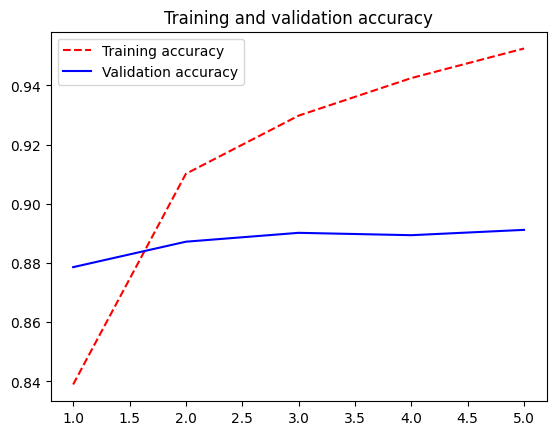

In [82]:
import matplotlib.pyplot as plt

accuracy = history.history["accuracy"]
val_accuracy = history.history["val_accuracy"]
epochs = range(1, len(accuracy) + 1)

plt.plot(epochs, accuracy, "r--", label="Training accuracy")
plt.plot(epochs, val_accuracy, "b", label="Validation accuracy")
plt.title("Training and validation accuracy")
plt.legend()
plt.show()

In [83]:
test_loss, test_acc = model.evaluate(bag_of_words_test_ds)
test_acc

782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8890 - loss: 0.2820


0.8889600038528442

#### Training a bigram model

In [84]:
max_tokens = 30_000
text_vectorization = layers.TextVectorization(
    max_tokens=max_tokens,
    split="whitespace",
    output_mode="multi_hot",
    ngrams=2,
)
text_vectorization.adapt(train_ds_no_labels)

bigram_train_ds = train_ds.map(
    lambda x, y: (text_vectorization(x), y), num_parallel_calls=8
)
bigram_val_ds = val_ds.map(
    lambda x, y: (text_vectorization(x), y), num_parallel_calls=8
)
bigram_test_ds = test_ds.map(
    lambda x, y: (text_vectorization(x), y), num_parallel_calls=8
)

In [85]:
x, y = next(bigram_train_ds.as_numpy_iterator())
x.shape

(32, 30000)

In [86]:
text_vectorization.get_vocabulary()[100:108]

[np.str_('how'),
 np.str_('most'),
 np.str_('him'),
 np.str_('dont'),
 np.str_('it was'),
 np.str_('one of'),
 np.str_('made'),
 np.str_('then')]

In [87]:
model = build_linear_classifier(max_tokens, "bigram_classifier")
model.fit(
    bigram_train_ds,
    validation_data=bigram_val_ds,
    epochs=5,
    callbacks=[early_stopping],
)

Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 12s 18ms/step - accuracy: 0.8623 - loss: 0.4006 - val_accuracy: 0.8900 - val_loss: 0.3058
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.9369 - loss: 0.2226 - val_accuracy: 0.8990 - val_loss: 0.2689
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - accuracy: 0.9606 - loss: 0.1631 - val_accuracy: 0.9000 - val_loss: 0.2568
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.9747 - loss: 0.1265 - val_accuracy: 0.9024 - val_loss: 0.2521
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step - accuracy: 0.9842 - loss: 0.1008 - val_accuracy: 0.9020 - val_loss: 0.2515


In [88]:
test_loss, test_acc = model.evaluate(bigram_test_ds)
test_acc

782/782 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.9017 - loss: 0.2489


0.9017199873924255

### Sequence models

- "this movie was great" → [12, 89, 7, 245]
- "great"가 문장 어디에 있었는지(순서) 정보가 그대로 남게됨
- multi_hot이었다면 great에 해당하는 위치만 1이 되고 순서 정보는 사라짐

In [97]:
max_length = 300
max_tokens = 3000
text_vectorization = layers.TextVectorization(
    max_tokens=max_tokens,
    split="whitespace",
    output_mode="int",
    output_sequence_length=max_length,
)
text_vectorization.adapt(train_ds_no_labels)

sequence_train_ds = train_ds.map(
    lambda x, y: (text_vectorization(x), y), num_parallel_calls=8
)
sequence_val_ds = val_ds.map(
    lambda x, y: (text_vectorization(x), y), num_parallel_calls=8
)
sequence_test_ds = test_ds.map(
    lambda x, y: (text_vectorization(x), y), num_parallel_calls=8
)

In [98]:
x, y = next(sequence_test_ds.as_numpy_iterator())
x.shape

(32, 300)

In [99]:
x

array([[   1,    1,    1, ...,    0,    0,    0],
       [  11,    7,    2, ...,   60,   80,    8],
       [  17,  148,   10, ...,    0,    0,    0],
       ...,
       [  52,    2,    1, ...,    0,    0,    0],
       [ 255, 2155,   37, ...,    0,    0,    0],
       [  52,   10,  207, ...,    0,    0,    0]])

#### Training a recurrent model

In [100]:
from keras import ops

class OneHotEncoding(keras.Layer):
    def __init__(self, depth, **kwargs):
        super().__init__(**kwargs)
        self.depth = depth

    def call(self, inputs):
        flat_inputs = ops.reshape(ops.cast(inputs, "int"), [-1])
        one_hot_vectors = ops.eye(self.depth)
        outputs = ops.take(one_hot_vectors, flat_inputs, axis=0)
        return ops.reshape(outputs, ops.shape(inputs) + (self.depth,))

one_hot_encoding = OneHotEncoding(max_tokens)

In [101]:
x, y = next(sequence_train_ds.as_numpy_iterator())
one_hot_encoding(x).shape

(32, 300, 3000)

In [102]:
hidden_dim = 64
inputs = keras.Input(shape=(max_length,), dtype="int32")
x = one_hot_encoding(inputs)
x = layers.Bidirectional(layers.LSTM(hidden_dim))(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)
model = keras.Model(inputs, outputs, name="lstm_with_one_hot")
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

In [103]:
model.summary(line_length=80)

Model: "lstm_with_one_hot"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                      ┃ Output Shape             ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)        │ (None, 300)              │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ one_hot_encoding_1                │ (None, 300, 3000)        │             0 │
│ (OneHotEncoding)                  │                          │               │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional)   │ (None, 128)              │     1,569,280 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ dropout_1 (Dropout)               │ (None, 128)              │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ dense_3 (Dense)                   │ (None, 1)                │           129 │
└───────────────────────────────────┴──────────────────────────┴───────────────┘

 Total params: 1,569,409 (5.99 MB)

 Trainable params: 1,569,409 (5.99 MB)

 Non-trainable params: 0 (0.00 B)

In [104]:
# ⚠️NOTE⚠️: The following fit call will error on a T4 GPU on the TensorFlow
# backend due to a bug in TensorFlow. If you the follow cell errors out,
# do one of the following:
# - Skip the following two cells.
# - Switch to the Jax or Torch backend and re-run this notebook.
# - Change the GPU type in your runtime (requires Colab Pro as of this writing).

In [109]:
model.fit(
    sequence_train_ds,
    validation_data=sequence_val_ds,
    epochs=5,
    callbacks=[early_stopping],
)

Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 26s 41ms/step - accuracy: 0.9059 - loss: 0.2438 - val_accuracy: 0.8586 - val_loss: 0.3391
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 27s 43ms/step - accuracy: 0.9097 - loss: 0.2283 - val_accuracy: 0.8546 - val_loss: 0.3734
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 25s 40ms/step - accuracy: 0.9241 - loss: 0.1978 - val_accuracy: 0.8480 - val_loss: 0.3815


In [110]:
test_loss, test_acc = model.evaluate(sequence_test_ds)
test_acc

782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.8637 - loss: 0.3325


0.8636800050735474

#### Understanding word embeddings

#### Using a word embedding

In [106]:
hidden_dim = 64
inputs = keras.Input(shape=(max_length,), dtype="int32")
x = keras.layers.Embedding(
    input_dim=max_tokens,
    output_dim=hidden_dim,
    mask_zero=True,
)(inputs)
x = keras.layers.Bidirectional(keras.layers.LSTM(hidden_dim))(x)
x = keras.layers.Dropout(0.5)(x)
outputs = keras.layers.Dense(1, activation="sigmoid")(x)
model = keras.Model(inputs, outputs, name="lstm_with_embedding")
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

In [107]:
model.summary(line_length=80)

Model: "lstm_with_embedding"

┏━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)          ┃ Output Shape      ┃     Param # ┃ Connected to       ┃
┡━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4         │ (None, 300)       │           0 │ -                  │
│ (InputLayer)          │                   │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ embedding (Embedding) │ (None, 300, 64)   │     192,000 │ input_layer_4[0][… │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ not_equal (NotEqual)  │ (None, 300)       │           0 │ input_layer_4[0][… │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ bidirectional_2       │ (None, 128)       │      66,048 │ embedding[0][0],   │
│ (Bidirectional)       │                   │             │ not_equal[0][0]    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ dropout_2 (Dropout)   │ (None, 128)       │           0 │ bidirectional_2[0… │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ dense_4 (Dense)       │ (None, 1)         │         129 │ dropout_2[0][0]    │
└───────────────────────┴───────────────────┴─────────────┴────────────────────┘

 Total params: 258,177 (1008.50 KB)

 Trainable params: 258,177 (1008.50 KB)

 Non-trainable params: 0 (0.00 B)

In [108]:
model.fit(
    sequence_train_ds,
    validation_data=sequence_val_ds,
    epochs=5,
    callbacks=[early_stopping],
)
test_loss, test_acc = model.evaluate(sequence_test_ds)
test_acc

Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 35s 45ms/step - accuracy: 0.7570 - loss: 0.5028 - val_accuracy: 0.7822 - val_loss: 0.4975
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 27s 43ms/step - accuracy: 0.8175 - loss: 0.4276 - val_accuracy: 0.8264 - val_loss: 0.4183
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 26s 42ms/step - accuracy: 0.7815 - loss: 0.4697 - val_accuracy: 0.8270 - val_loss: 0.3982
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 25s 40ms/step - accuracy: 0.8757 - loss: 0.3125 - val_accuracy: 0.8190 - val_loss: 0.3913
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 25s 40ms/step - accuracy: 0.8876 - loss: 0.2811 - val_accuracy: 0.8616 - val_loss: 0.3261
782/782 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.8651 - loss: 0.3237


0.8650799989700317

#### Pretraining a word embedding

In [111]:
imdb_vocabulary = text_vectorization.get_vocabulary()
tokenize_no_padding = keras.layers.TextVectorization(
    vocabulary=imdb_vocabulary,
    split="whitespace",
    output_mode="int",
)

In [112]:
import tensorflow as tf

context_size = 4
window_size = 9

def window_data(token_ids):
    num_windows = tf.maximum(tf.size(token_ids) - context_size * 2, 0)
    windows = tf.range(window_size)[None, :]
    windows = windows + tf.range(num_windows)[:, None]
    windowed_tokens = tf.gather(token_ids, windows)
    return tf.data.Dataset.from_tensor_slices(windowed_tokens)

def split_label(window):
    left = window[:context_size]
    right = window[context_size + 1 :]
    bag = tf.concat((left, right), axis=0)
    label = window[4]
    return bag, label

dataset = keras.utils.text_dataset_from_directory(
    imdb_extract_dir / "train", batch_size=None
)
dataset = dataset.map(lambda x, y: x, num_parallel_calls=8)
dataset = dataset.map(tokenize_no_padding, num_parallel_calls=8)
dataset = dataset.interleave(window_data, cycle_length=8, num_parallel_calls=8)
dataset = dataset.map(split_label, num_parallel_calls=8)

Found 75000 files belonging to 3 classes.


In [113]:
hidden_dim = 32
inputs = keras.Input(shape=(2 * context_size,))

#  학습된 임베딩 벡터 추출
cbow_embedding = layers.Embedding(
    max_tokens,
    hidden_dim,
)
x = cbow_embedding(inputs)
x = layers.GlobalAveragePooling1D()(x)
outputs = layers.Dense(max_tokens, activation="sigmoid")(x)
cbow_model = keras.Model(inputs, outputs)
cbow_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["sparse_categorical_accuracy"],
)

In [114]:
cbow_model.summary(line_length=80)

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                      ┃ Output Shape             ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)        │ (None, 8)                │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ embedding_1 (Embedding)           │ (None, 8, 64)            │       192,000 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ global_average_pooling1d          │ (None, 64)               │             0 │
│ (GlobalAveragePooling1D)          │                          │               │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ dense_5 (Dense)                   │ (None, 3000)             │       195,000 │
└───────────────────────────────────┴──────────────────────────┴───────────────┘

 Total params: 387,000 (1.48 MB)

 Trainable params: 387,000 (1.48 MB)

 Non-trainable params: 0 (0.00 B)

In [115]:
dataset = dataset.batch(1024).cache()
cbow_model.fit(dataset, epochs=4)

Epoch 1/4
16503/16503 ━━━━━━━━━━━━━━━━━━━━ 539s 33ms/step - loss: 5.1927 - sparse_categorical_accuracy: 0.1647
Epoch 2/4
   56/16503 ━━━━━━━━━━━━━━━━━━━━ 46s 3ms/step - loss: 4.8571 - sparse_categorical_accuracy: 0.1877

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


16503/16503 ━━━━━━━━━━━━━━━━━━━━ 40s 2ms/step - loss: 4.8143 - sparse_categorical_accuracy: 0.1851
Epoch 3/4
16503/16503 ━━━━━━━━━━━━━━━━━━━━ 39s 2ms/step - loss: 4.7413 - sparse_categorical_accuracy: 0.1867
Epoch 4/4
16503/16503 ━━━━━━━━━━━━━━━━━━━━ 38s 2ms/step - loss: 4.7123 - sparse_categorical_accuracy: 0.1872


#### Using the pretrained embedding for classification

In [117]:
inputs = keras.Input(shape=(max_length,))

# 새로 만든(아직 랜덤 초기화된) 임베딩 레이어. mask_zero=True로 패딩값 0을 LSTM이 무시하도록 처리
lstm_embedding = layers.Embedding(
    input_dim=max_tokens,
    output_dim=hidden_dim,
    mask_zero=True,
)
x = lstm_embedding(inputs)
x = layers.Bidirectional(layers.LSTM(hidden_dim))(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)
model = keras.Model(inputs, outputs, name="lstm_with_cbow")

In [118]:
# @title pretrained 가중치 주입
# lstm_embedding의 랜덤 초기값이 CBOW가 학습해둔 "의미 있는" 벡터값으로 통째로 교체
lstm_embedding.embeddings.assign(cbow_embedding.embeddings)

Array([[ 2.14574076e-02,  3.49624418e-02,  4.73978557e-02, ...,
         1.88628584e-03,  3.01537029e-02,  4.21035923e-02],
       [-1.06254935e-01, -1.54062882e-01, -6.75495744e-01, ...,
        -1.16306134e-02, -3.21554691e-02, -3.32552157e-02],
       [ 1.43479073e+00,  4.38485295e-01,  5.41453898e-01, ...,
        -1.06732261e+00,  1.47939253e+00,  4.29400951e-01],
       ...,
       [-6.06174052e-01, -6.59550667e-01, -2.58177787e-01, ...,
        -8.90132368e-01, -1.58313230e-01, -1.12344515e+00],
       [ 6.94375694e-01, -2.10445210e-01,  2.36591008e-02, ...,
         8.32735837e-01,  7.85646856e-01,  8.19500327e-01],
       [-1.13248527e-01, -2.00593203e-01, -1.36515284e+00, ...,
         2.37359047e+00,  1.18925941e+00,  6.08687162e-01]],      dtype=float32)

In [119]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"],
)
model.fit(
    sequence_train_ds,
    validation_data=sequence_val_ds,
    epochs=5,
    callbacks=[early_stopping],
)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 29s 42ms/step - accuracy: 0.7148 - loss: 0.5548 - val_accuracy: 0.6936 - val_loss: 0.5932
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 27s 43ms/step - accuracy: 0.8116 - loss: 0.4187 - val_accuracy: 0.7596 - val_loss: 0.4793
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 25s 39ms/step - accuracy: 0.8520 - loss: 0.3509 - val_accuracy: 0.8550 - val_loss: 0.3530
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 25s 40ms/step - accuracy: 0.8842 - loss: 0.2859 - val_accuracy: 0.8630 - val_loss: 0.3051
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 25s 40ms/step - accuracy: 0.8994 - loss: 0.2517 - val_accuracy: 0.8700 - val_loss: 0.3061
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 26s 41ms/step - accuracy: 0.9116 - loss: 0.2256 - val_accuracy: 0.8686 - val_loss: 0.3128


In [120]:
test_loss, test_acc = model.evaluate(sequence_test_ds)
test_acc

782/782 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.8762 - loss: 0.2911


0.8761599659919739